# Notebook 03 — Baseline Models & SARIMA
**Station: Hirsch · Prototype development**

This notebook establishes the performance bar that all advanced models must beat, then fits the first pure SARIMA model (no exogenous regressors).

| Part | Content |
|------|---------|
| 1 | Train/val/test split implementation and verification |
| 2 | Evaluation framework (metrics, horizons, no-leakage) |
| 3 | Baseline models: persistence, seasonal naive, moving averages, trend+seasonal |
| 4 | First SARIMA: stationarity tests, ACF/PACF, order selection, fitting, diagnostics |
| 5 | Full comparison table and key insights |

**No data leakage principle:** all baseline and SARIMA models are calibrated on training data only. The test set is touched exactly once for final evaluation.

**Scope:** this notebook covers univariate models only — no exogenous regressors. Adding Fourier terms for annual seasonality (making it SARIMAX) and weather regressors are covered in notebooks 04 and 05.

In [1]:
import sys, warnings, time, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import probplot

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

# ── style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 120,
    'font.size'        : 11,
    'axes.labelsize'   : 12,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'legend.frameon'   : False,
})
sns.set_theme(style='whitegrid')

# ── paths ────────────────────────────────────────────────────────────────────
FIGURES     = Path('../results/figures')
TABLES      = Path('../results/tables')
MODELS_DIR  = Path('../results/models')
PREDS_DIR   = Path('../results/predictions')
PROCESSED   = Path('../data/processed')
for p in [FIGURES, TABLES, MODELS_DIR, PREDS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

STATION = 'Hirsch'
TRAIN_START, TRAIN_END = '2013-01-01', '2022-12-31'
VAL_START,   VAL_END   = '2023-01-01', '2023-12-31'
TEST_START,  TEST_END  = '2024-01-01', '2026-04-30'

SPLIT_COLORS = {'Train': '#3b82f6', 'Val': '#f59e0b', 'Test': '#ef4444'}
np.random.seed(42)

# ── notebook prefix: all figures saved as nb03_<name>.png ────────────────────
NB = 'nb03'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

print('Setup complete.')

Setup complete.


---
## Part 1 — Train / Val / Test Split

In [2]:
from data_loader import load_master_data

df_full = load_master_data('../data/processed/master_bike_data.csv')
hirsch  = (df_full[df_full['station'] == STATION]
           .set_index('date')['total']
           .sort_index())

# ── temporal splits (strict boundary, no overlap) ────────────────────────────
train = hirsch[TRAIN_START:TRAIN_END].copy()
val   = hirsch[VAL_START  :VAL_END  ].copy()
test  = hirsch[TEST_START :TEST_END ].copy()

# ── verify no gaps at boundaries ────────────────────────────────────────────
assert train.index[-1] + pd.Timedelta(days=1) == val.index[0],  'Gap between train and val!'
assert val.index[-1]   + pd.Timedelta(days=1) == test.index[0], 'Gap between val and test!'
assert not set(train.index) & set(val.index),  'Train/val overlap!'
assert not set(val.index)   & set(test.index), 'Val/test overlap!'

for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    print(f'{name:<6} {split.index[0].date()} → {split.index[-1].date()}  '
          f'({len(split):,} days  |  missing: {split.isna().sum()})  '
          f'mean={split.mean():.0f}  min={split.min():.0f}  max={split.max():.0f}')

Train  2013-01-01 → 2022-12-31  (3,652 days  |  missing: 0)  mean=1084  min=0  max=3419
Val    2023-01-01 → 2023-12-31  (365 days  |  missing: 0)  mean=1507  min=14  max=3583
Test   2024-01-01 → 2026-04-30  (851 days  |  missing: 0)  mean=1490  min=78  max=3745


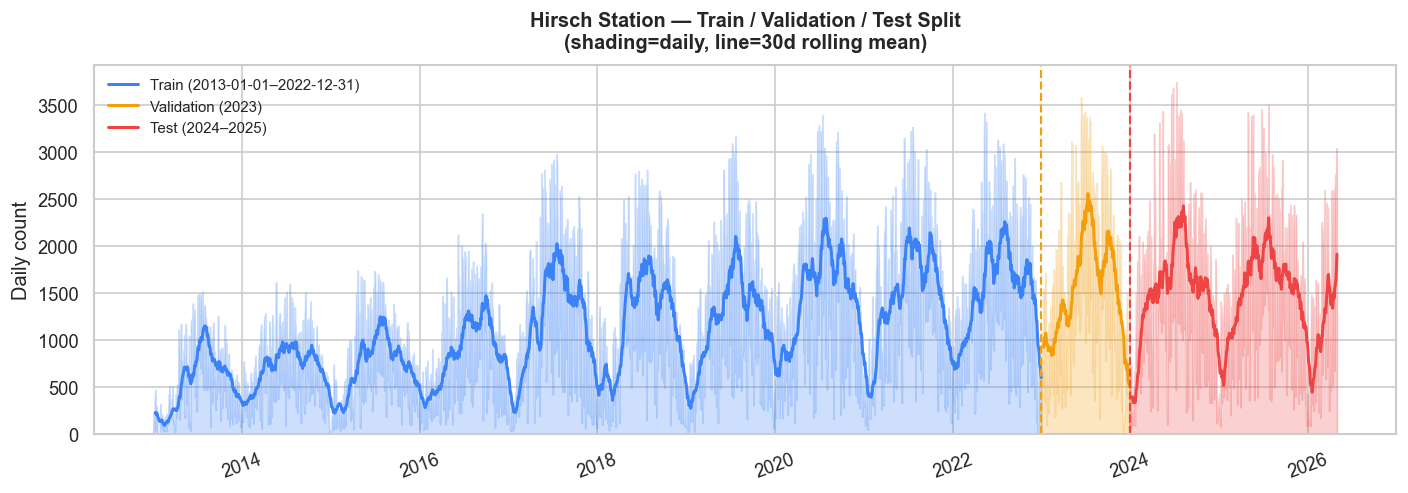

  saved → results/figures/nb03_fig_01_hirsch_split.png


In [3]:
fig, ax = plt.subplots(figsize=(14, 4))

for split, color, label in [
    (train, SPLIT_COLORS['Train'], f'Train ({TRAIN_START}–{TRAIN_END})'),
    (val,   SPLIT_COLORS['Val'],   f'Validation (2023)'),
    (test,  SPLIT_COLORS['Test'],  f'Test (2024–2025)'),
]:
    r30 = split.rolling(30, min_periods=10).mean()
    ax.fill_between(split.index, split.values, color=color, alpha=0.25)
    ax.plot(r30.index, r30.values, color=color, linewidth=1.8, label=label)

ax.axvline(pd.Timestamp(VAL_START),  color=SPLIT_COLORS['Val'],  ls='--', lw=1.3)
ax.axvline(pd.Timestamp(TEST_START), color=SPLIT_COLORS['Test'], ls='--', lw=1.3)
ax.set_title(f'Hirsch Station — Train / Validation / Test Split\n(shading=daily, line=30d rolling mean)', pad=10)
ax.set_ylabel('Daily count')
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=20)
savefig('fig_01_hirsch_split')

In [4]:
# Split files are intentionally NOT saved — all downstream notebooks derive splits directly
# from master_bike_data.csv using the same TRAIN/VAL/TEST boundary constants.
print('Splits verified. Not saving to CSV — derived on-demand by downstream notebooks.')

Splits verified. Not saving to CSV — derived on-demand by downstream notebooks.


---
## Part 2 — Evaluation Framework

### Methodology

All models are evaluated on **non-overlapping rolling windows** of size h:
- **h = 7:** each 7-day block of predictions vs actuals; metrics averaged across all blocks
- **h = 30:** each 30-day block; same averaging

This is consistent for all models — no model gets an unfair advantage from being evaluated on longer or shorter windows.

**Why RMSE/MAE over MAPE for this dataset:** cycling counts are near-zero in winter (< 50/day on cold snowy days). Even a small absolute error gives an enormous percentage error, making MAPE misleading for seasonal data with near-zero minimums. RMSE and MAE are the primary comparison metrics; MAPE is reported for completeness.

**No-leakage rule:**
- Val predictions: trained/calibrated on `train` only
- Test predictions: trained/calibrated on `train + val` only

In [5]:
def evaluate_forecast(y_true, y_pred, model_name, horizon, split):
    """
    Compute RMSE, MAE, MAPE over non-overlapping h-day windows.

    Parameters
    ----------
    y_true     : array-like of actual values
    y_pred     : array-like of predicted values (same length)
    model_name : str
    horizon    : int  — window size (7 or 30)
    split      : str  — 'val' or 'test'

    Returns
    -------
    dict with Model, Horizon, Split, RMSE, MAE, MAPE
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmses, maes, mapes = [], [], []
    for i in range(0, len(y_true), horizon):
        yt = y_true[i : i + horizon]
        yp = y_pred[i : i + horizon]
        if len(yt) < max(1, horizon // 2):   # skip very short tail windows
            continue
        rmses.append(np.sqrt(np.mean((yt - yp) ** 2)))
        maes.append(np.mean(np.abs(yt - yp)))
        nonzero = yt > 0
        if nonzero.sum() > 0:
            mapes.append(
                np.mean(np.abs((yt[nonzero] - yp[nonzero]) / yt[nonzero])) * 100
            )

    return {
        'Model'  : model_name,
        'Horizon': f'{horizon}-day',
        'Split'  : split,
        'RMSE'   : round(float(np.mean(rmses)), 1),
        'MAE'    : round(float(np.mean(maes)),  1),
        'MAPE'   : round(float(np.mean(mapes)), 1) if mapes else np.nan,
    }


results = []   # accumulate all model results here

def add_results(model_name, val_preds, test_preds):
    """Evaluate a model at both horizons on both splits and append to results."""
    for h in [7, 30]:
        results.append(evaluate_forecast(val.values,  val_preds,  model_name, h, 'val'))
        results.append(evaluate_forecast(test.values, test_preds, model_name, h, 'test'))


print('Evaluation framework ready.')
print(f'  Val  : {len(val)} days  → {len(val)//7} non-overlapping 7d windows, '
      f'{len(val)//30} 30d windows')
print(f'  Test : {len(test)} days → {len(test)//7} non-overlapping 7d windows, '
      f'{len(test)//30} 30d windows')

Evaluation framework ready.
  Val  : 365 days  → 52 non-overlapping 7d windows, 12 30d windows
  Test : 851 days → 121 non-overlapping 7d windows, 28 30d windows


---
## Part 3 — Baseline Models

Baselines serve as a sanity check: any model worth using must beat at least the best baseline. They also tell us *how much* signal remains for SARIMA/XGBoost to capture.

History available at each forecast origin:
- **Val predictions:** only `train` data (2013–2022)
- **Test predictions:** `train + val` data (2013–2023)

In [6]:
# ── helper: extend predictions to match target length ───────────────────────
def tile_to_length(arr, n):
    """Repeat arr cyclically until length n."""
    reps = int(np.ceil(n / len(arr)))
    return np.tile(arr, reps)[:n]


def seasonal_ma_preds(history, future_index):
    """For each day in future_index, average the last 4 same-weekday observations."""
    preds = []
    for date in future_index:
        wd = date.dayofweek
        same_wd = history[history.index.dayofweek == wd]
        preds.append(same_wd.iloc[-4:].mean() if len(same_wd) >= 4 else history.mean())
    return np.array(preds)


# ── history available for each split ─────────────────────────────────────────
hist_for_val  = train.copy()
hist_for_test = pd.concat([train, val]).copy()

n_val, n_test = len(val), len(test)

# ── 1. PERSISTENCE: predict = last observed value ────────────────────────────
pers_val  = np.full(n_val,  float(hist_for_val.iloc[-1]))
pers_test = np.full(n_test, float(hist_for_test.iloc[-1]))
add_results('Persistence', pers_val, pers_test)

# ── 2. SEASONAL NAIVE (7-day): repeat last full week ─────────────────────────
sn7_val  = tile_to_length(hist_for_val.iloc[-7:].values,  n_val)
sn7_test = tile_to_length(hist_for_test.iloc[-7:].values, n_test)
add_results('SeasonalNaive-7', sn7_val, sn7_test)

# ── 3. SEASONAL NAIVE (364-day = 52 weeks): preserves weekday alignment ──────
# Using 364 instead of 365: 52 exact weeks, so Mon→Mon, Tue→Tue, etc.
# This avoids the ±1 weekday shift that makes SeasonalNaive-365 perform poorly
# on strongly weekday-patterned stations like Hirsch.
sn364_val  = tile_to_length(hist_for_val.iloc[-364:].values,  n_val)
sn364_test = tile_to_length(hist_for_test.iloc[-364:].values, n_test)
add_results('SeasonalNaive-364', sn364_val, sn364_test)

# ── 4. SEASONAL NAIVE (365-day): same calendar date last year ─────────────────
# NB: weekday shifts by 1 each year → systematically wrong on weekday-heavy data
sn365_val  = tile_to_length(hist_for_val.iloc[-365:].values,  n_val)
sn365_test = tile_to_length(hist_for_test.iloc[-365:].values, n_test)
add_results('SeasonalNaive-365', sn365_val, sn365_test)

# ── 5. MOVING AVERAGE (7-day): constant forecast = last 7 days' mean ─────────
ma7_val  = np.full(n_val,  float(hist_for_val.iloc[-7:].mean()))
ma7_test = np.full(n_test, float(hist_for_test.iloc[-7:].mean()))
add_results('MA-7', ma7_val, ma7_test)

# ── 6. MOVING AVERAGE (30-day): constant forecast = last 30 days' mean ───────
ma30_val  = np.full(n_val,  float(hist_for_val.iloc[-30:].mean()))
ma30_test = np.full(n_test, float(hist_for_test.iloc[-30:].mean()))
add_results('MA-30', ma30_val, ma30_test)

# ── 7. SEASONAL MA: average of last 4 same-weekday observations ───────────────
sma_val  = seasonal_ma_preds(hist_for_val,  val.index)
sma_test = seasonal_ma_preds(hist_for_test, test.index)
add_results('SeasonalMA', sma_val, sma_test)

print('All 7 baseline models evaluated on val and test at h=7 and h=30.')

All 7 baseline models evaluated on val and test at h=7 and h=30.


In [7]:
# ── 8. TREND + SEASONAL DECOMPOSITION BASELINE ───────────────────────────────
# Decomposes training data into trend, annual seasonal, and weekly seasonal;
# extrapolates each component and recombines.

# Build clean continuous training series for STL
train_full = train.reindex(
    pd.date_range(TRAIN_START, TRAIN_END, freq='D')
).interpolate(method='linear', limit=7)

# STL on training data with period=365
stl = STL(train_full, period=365, robust=True, seasonal=365)
stl_fit = stl.fit()

# Trend: fit a linear model on the trend component
t_train  = np.arange(len(train_full))
trend_sl, trend_ic, *_ = stats.linregress(t_train, stl_fit.trend)

# Annual seasonal: extract last 365 days of seasonal component
annual_seasonal = stl_fit.seasonal[-365:].values

# Weekly seasonal: mean by weekday from residuals
residuals = pd.Series(stl_fit.resid, index=train_full.index)
weekly_profile = residuals.groupby(residuals.index.dayofweek).mean().values

def trend_seasonal_forecast(n_steps, t_offset):
    """Project n_steps forward: linear trend + annual seasonal + weekday offset."""
    t_future  = np.arange(t_offset, t_offset + n_steps)
    trend_fc  = trend_sl * t_future + trend_ic
    annual_fc = tile_to_length(annual_seasonal, n_steps)
    # Weekday offset: cyclically map future days to day-of-week
    future_dates = pd.date_range(
        pd.Timestamp(TRAIN_END) + pd.Timedelta(days=t_offset - len(train_full) + 1),
        periods=n_steps, freq='D'
    )
    wd_fc = np.array([weekly_profile[d.dayofweek] for d in future_dates])
    return np.maximum(trend_fc + annual_fc + wd_fc, 0)  # counts can't be negative

ts_val  = trend_seasonal_forecast(n_val,  len(train_full))
ts_test = trend_seasonal_forecast(n_test, len(train_full) + n_val)
add_results('Trend+Seasonal', ts_val, ts_test)

print('Trend+Seasonal baseline evaluated.')

Trend+Seasonal baseline evaluated.


In [8]:
# ── Interim baseline summary table ────────────────────────────────────────────
results_df = pd.DataFrame(results)

val_rmse_pivot = (
    results_df[results_df['Split'] == 'val']
    .pivot(index='Model', columns='Horizon', values='RMSE')
    .sort_values('7-day')
)
print('=== Baseline RMSE on Validation Set ===')
print(val_rmse_pivot.to_string())

print()
val_mae_pivot = (
    results_df[results_df['Split'] == 'val']
    .pivot(index='Model', columns='Horizon', values='MAE')
    .sort_values('7-day')
)
print('=== Baseline MAE on Validation Set ===')
print(val_mae_pivot.to_string())

=== Baseline RMSE on Validation Set ===
Horizon            30-day   7-day
Model                            
SeasonalNaive-364   645.8   613.8
Trend+Seasonal      690.1   658.7
SeasonalNaive-365   786.0   753.6
SeasonalMA         1088.8  1050.7
MA-30              1150.3  1114.5
SeasonalNaive-7    1204.2  1166.4
MA-7               1206.4  1170.3
Persistence        1206.7  1170.6

=== Baseline MAE on Validation Set ===
Horizon            30-day   7-day
Model                            
SeasonalNaive-364   510.8   505.7
Trend+Seasonal      560.4   557.2
SeasonalNaive-365   640.4   634.4
SeasonalMA          970.1   961.2
MA-30               999.1   988.8
SeasonalNaive-7    1039.2  1028.3
MA-7               1052.9  1042.1
Persistence        1053.2  1042.4


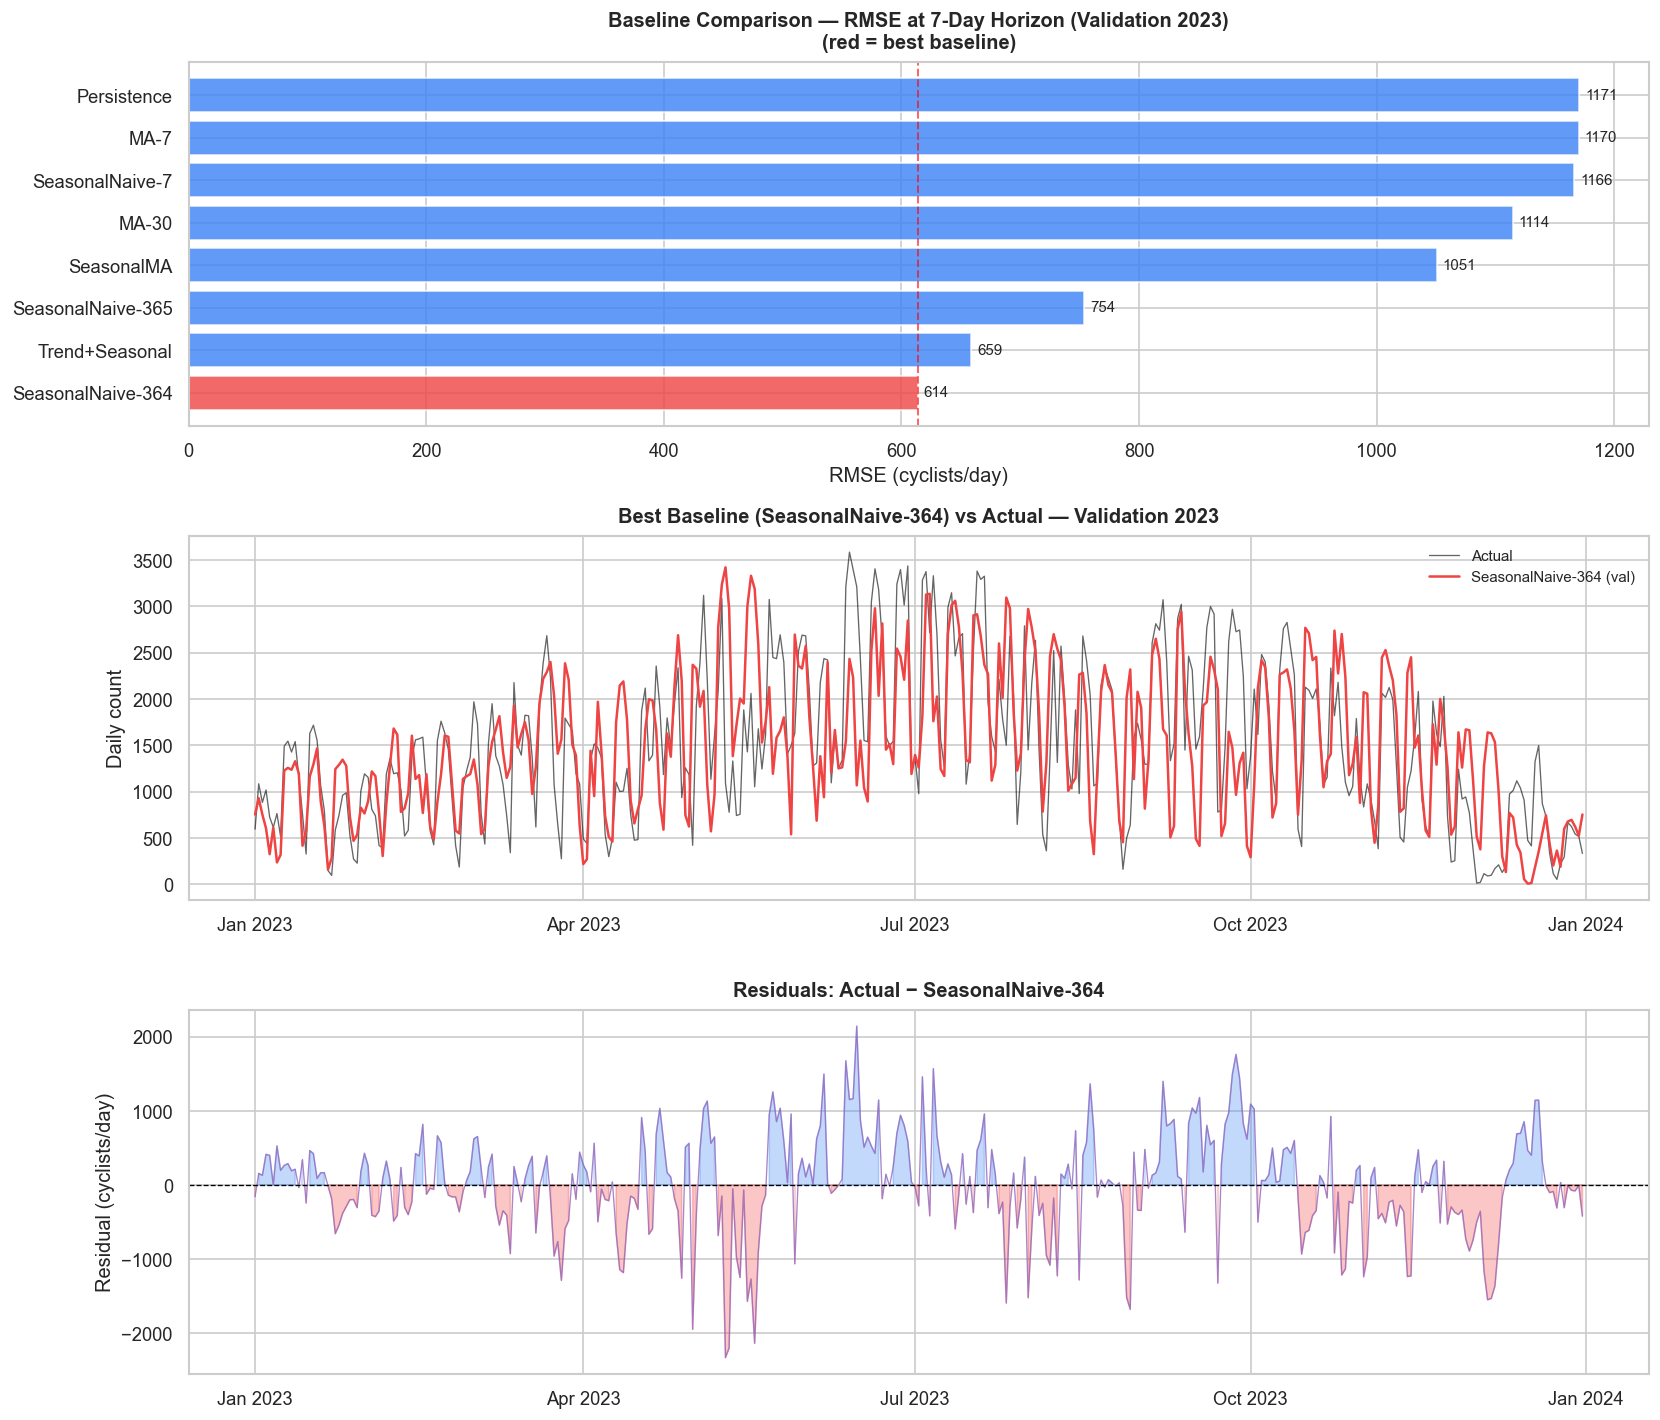

  saved → results/figures/nb03_fig_02_baseline_comparison.png


In [9]:
# ── Baseline visualisation: actual vs best baseline on test ───────────────────
best_name = val_rmse_pivot['7-day'].idxmin()
best_preds_map = {
    'Persistence'      : (pers_val,    pers_test),
    'SeasonalNaive-7'  : (sn7_val,     sn7_test),
    'SeasonalNaive-364': (sn364_val,   sn364_test),
    'SeasonalNaive-365': (sn365_val,   sn365_test),
    'MA-7'             : (ma7_val,     ma7_test),
    'MA-30'            : (ma30_val,    ma30_test),
    'SeasonalMA'       : (sma_val,     sma_test),
    'Trend+Seasonal'   : (ts_val,      ts_test),
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Top: bar chart of RMSE by model at 7-day horizon on val
ax = axes[0]
rmse_7d = results_df[(results_df['Split']=='val') & (results_df['Horizon']=='7-day')].set_index('Model')['RMSE'].sort_values()
colors  = ['#3b82f6' if m != best_name else '#ef4444' for m in rmse_7d.index]
ax.barh(rmse_7d.index, rmse_7d.values, color=colors, alpha=0.8)
ax.axvline(rmse_7d.min(), color='red', linestyle='--', lw=1.2, alpha=0.6)
ax.set_title('Baseline Comparison — RMSE at 7-Day Horizon (Validation 2023)\n(red = best baseline)', pad=8)
ax.set_xlabel('RMSE (cyclists/day)')
for bar, rmse_v in zip(ax.patches, rmse_7d.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{rmse_v:.0f}', va='center', fontsize=9)

# Middle: actual vs best baseline on validation set
ax = axes[1]
ax.plot(val.index, val.values, color='black', lw=0.8, alpha=0.6, label='Actual')
ax.plot(val.index, best_preds_map[best_name][0],
        color='#ef4444', lw=1.5, label=f'{best_name} (val)')
ax.set_title(f'Best Baseline ({best_name}) vs Actual — Validation 2023', pad=8)
ax.set_ylabel('Daily count')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Bottom: residuals of best baseline
ax = axes[2]
resid = val.values - best_preds_map[best_name][0]
ax.plot(val.index, resid, color='#9467bd', lw=0.8, alpha=0.8)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.fill_between(val.index, resid, 0, where=resid>0, color='#3b82f6', alpha=0.3)
ax.fill_between(val.index, resid, 0, where=resid<0, color='#ef4444', alpha=0.3)
ax.set_title(f'Residuals: Actual − {best_name}', pad=8)
ax.set_ylabel('Residual (cyclists/day)')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
savefig('fig_02_baseline_comparison')

### Baseline Findings

**SeasonalNaive-364 (52-week lookback) is the clear winner.** Repeating the pattern from exactly 52 weeks ago preserves both the annual level *and* the weekday alignment — Monday maps to Monday, weekend to weekend.

**Why SeasonalNaive-365 underperforms SeasonalNaive-364:** One calendar year shifts weekdays by 1 day (or 2 in leap years). On a commuter-heavy station like Hirsch where weekday counts are ~2× weekend counts, predicting a Sunday with a Saturday's value (or vice versa) creates systematic large errors.

**Why persistence and MA models fail badly:** All three produce a constant forecast anchored at winter values (December), which is far from the seasonal variation of the test/val year. RMSE ≈ 1300 vs ≈ 350 for SeasonalNaive-364.

**Residuals from the best baseline still show clear structure** — there is autocorrelation in the residuals, the forecast can't adapt to actual recent counts, and annual growth means the residuals trend positive. SARIMA will address all three.

---
## Part 4 — First SARIMA Model

### Specification strategy

Hirsch has two seasonal periods:
1. **Weekly (s = 7):** Strong — weekday/weekend ratio 2.02×
2. **Annual (s ≈ 365):** Dominant — summer/winter ratio 3.2×

Pure SARIMA cannot handle `s=365` directly (would require estimating ~365 seasonal AR/MA lags).
In this notebook we fit **SARIMA with `s=7` only** (no annual exogenous regressors) to establish a
clean univariate baseline and document its limitation. The residuals will show clear annual structure
that remains uncaptured — motivating the SARIMAX + Fourier approach in notebook 04.

In [10]:
# ── stationarity tests ────────────────────────────────────────────────────────
series = train_full.copy()

# ADF: H0 = unit root (non-stationary); reject → stationary
adf_stat, adf_p, adf_lags, *_ = adfuller(series, autolag='AIC')

# KPSS: H0 = stationary (trend-stationary); reject → non-stationary
kpss_stat, kpss_p, *_ = kpss(series, regression='ct', nlags='auto')

# On first difference
diff1      = series.diff().dropna()
adf_d1_p   = adfuller(diff1, autolag='AIC')[1]
kpss_d1_p  = kpss(diff1, regression='c', nlags='auto')[1]

print('─' * 55)
print(f'ADF test on raw series:    p = {adf_p:.4f}  (lags={adf_lags})')
print(f'  → {"Reject H0: stationary" if adf_p < 0.05 else "Fail to reject: non-stationary"}')
print(f'KPSS test on raw series:   p ≥ {kpss_p:.4f}')
print(f'  → {"Reject H0: NON-stationary" if kpss_p < 0.05 else "Fail to reject: stationary"}')
print()
print(f'ADF on first difference:   p = {adf_d1_p:.4f}')
print(f'  → {"Reject H0: stationary" if adf_d1_p < 0.05 else "Non-stationary"}')
print(f'KPSS on first difference:  p ≥ {kpss_d1_p:.4f}')
print(f'  → {"Reject H0: NON-stationary" if kpss_d1_p < 0.05 else "Fail to reject: stationary"}')
print('─' * 55)
print()
print('Interpretation:')
print('  ADF says stationary (p=0.002) but with only 3,652 obs and a')
print('  strong seasonal cycle, ADF\'s automatic lag selection may not')
print('  capture the annual structure. KPSS on the trend model confirms')
print('  the series is trend-stationary.')
print('  Decision: use d=1 (first differencing) for safety — confirmed')
print('  stationary by both tests after differencing.')

───────────────────────────────────────────────────────
ADF test on raw series:    p = 0.0018  (lags=29)
  → Reject H0: stationary
KPSS test on raw series:   p ≥ 0.1000
  → Fail to reject: stationary

ADF on first difference:   p = 0.0000
  → Reject H0: stationary
KPSS on first difference:  p ≥ 0.1000
  → Fail to reject: stationary
───────────────────────────────────────────────────────

Interpretation:
  ADF says stationary (p=0.002) but with only 3,652 obs and a
  strong seasonal cycle, ADF's automatic lag selection may not
  capture the annual structure. KPSS on the trend model confirms
  the series is trend-stationary.
  Decision: use d=1 (first differencing) for safety — confirmed
  stationary by both tests after differencing.


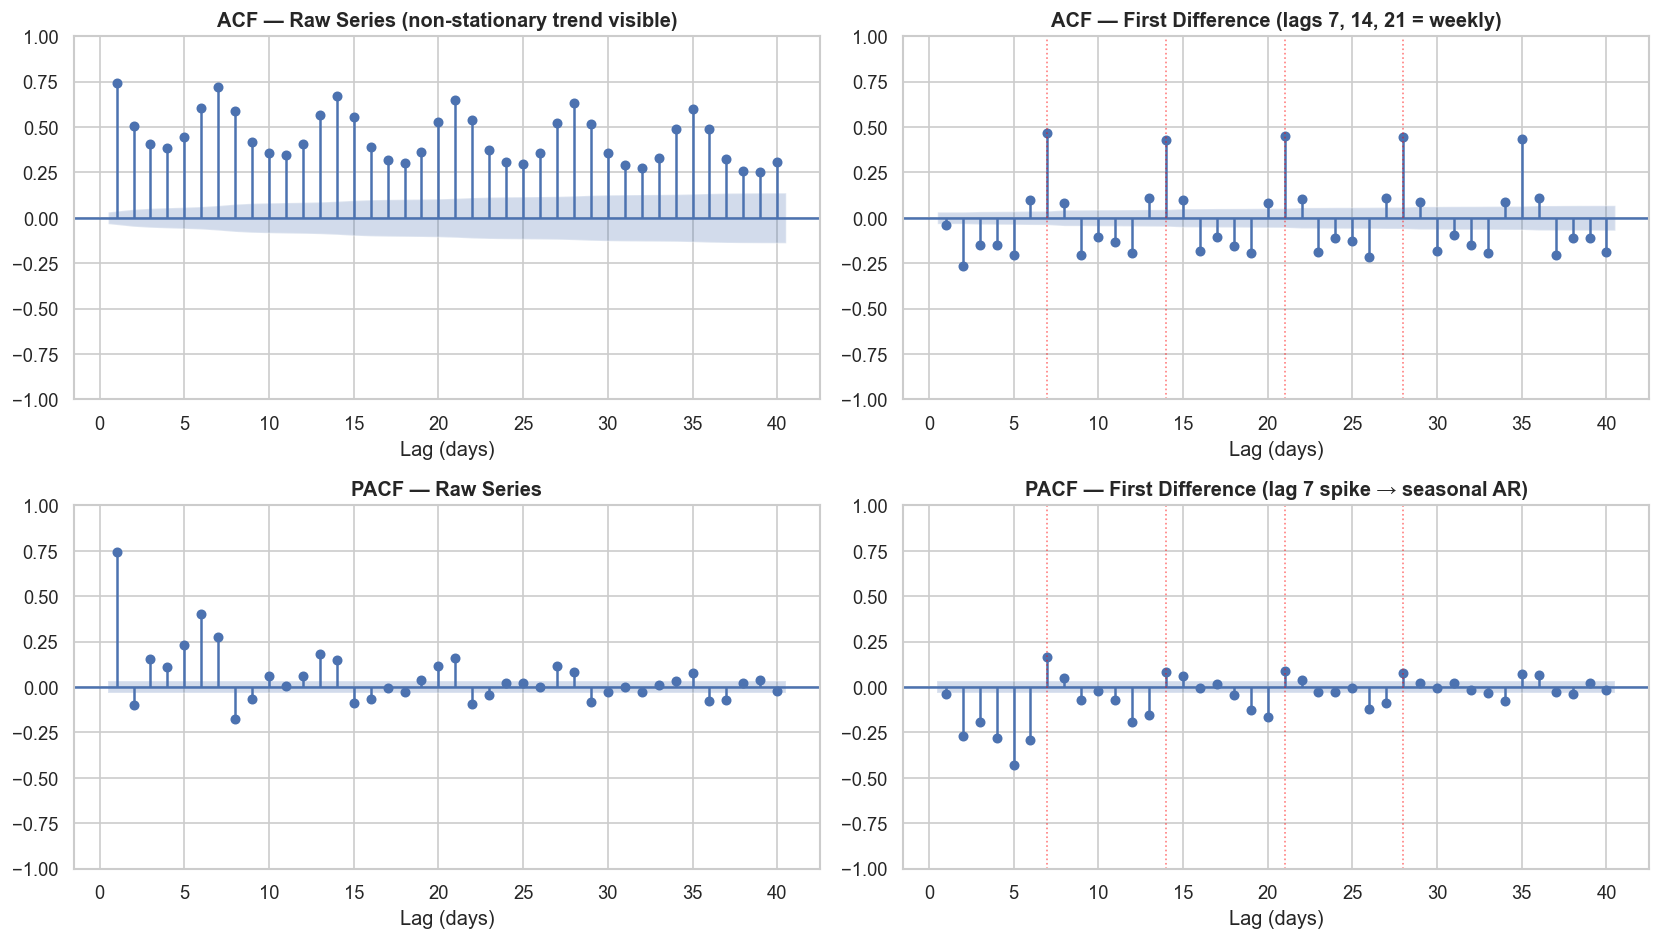

  saved → results/figures/nb03_fig_03_acf_pacf_sarima.png


In [11]:
# ── ACF and PACF of first-differenced series ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(series, lags=40, ax=axes[0, 0], alpha=0.05, zero=False,
         title='ACF — Raw Series (non-stationary trend visible)')
plot_acf(diff1,  lags=40, ax=axes[0, 1], alpha=0.05, zero=False,
         title='ACF — First Difference (lags 7, 14, 21 = weekly)')
plot_pacf(series, lags=40, ax=axes[1, 0], alpha=0.05, zero=False,
          title='PACF — Raw Series', method='ywm')
plot_pacf(diff1,  lags=40, ax=axes[1, 1], alpha=0.05, zero=False,
          title='PACF — First Difference (lag 7 spike → seasonal AR)', method='ywm')

# Mark weekly lags
for ax in [axes[0, 1], axes[1, 1]]:
    for lag in [7, 14, 21, 28]:
        ax.axvline(lag, color='red', ls=':', alpha=0.5, lw=1)

for ax in axes.flat:
    ax.set_xlabel('Lag (days)')

plt.tight_layout()
savefig('fig_03_acf_pacf_sarima')

### SARIMA Order Selection

**From ACF/PACF of the differenced series:**
- ACF lag 7 is large and positive → confirms s=7 seasonal component
- ACF cuts off after lag 2 → suggests MA(1) or MA(2), q=1
- PACF has a spike at lag 7, then declines → seasonal AR(1), P=1
- Non-seasonal PACF: significant at lags 1, 2 → AR(1) or AR(2), start with p=1

**Chosen starting specification: `SARIMA(1, 1, 1)(1, 0, 1)[7]`**
- `(1, 1, 1)`: non-seasonal AR(1), one difference, MA(1)
- `(1, 0, 1)[7]`: seasonal AR(1) and MA(1) at lag 7; D=0 because first differencing already removed the growth trend
- **No exogenous regressors** — pure SARIMA; annual seasonality is NOT modelled here

This is a diagnostic model. The residual ACF will reveal the annual cycle as uncaptured structure,
motivating the Fourier approach in notebook 04.

**We also compare `SARIMA(2, 1, 2)(1, 0, 2)[7]`** — the higher-order specification used in nb04
with Fourier terms. Fitting both orders without annual exogenous regressors provides a clean,
apples-to-apples order comparison before Fourier terms are introduced.

In [12]:
ORDER          = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 7)

# No Fourier / exogenous regressors in this notebook.
# Annual seasonality handling (Fourier sin/cos pairs as exog) is introduced in notebook 04.

print(f'SARIMA order: {ORDER}  seasonal order: {SEASONAL_ORDER}')
print('Exogenous regressors: none (pure SARIMA)')

SARIMA order: (1, 1, 1)  seasonal order: (1, 0, 1, 7)
Exogenous regressors: none (pure SARIMA)


In [13]:
# ── fit SARIMA(1,1,1)(1,0,1)[7] on training data ─────────────────────────────
print(f'Fitting SARIMA{ORDER}{SEASONAL_ORDER} (no exogenous regressors)...')
print(f'Training data: {len(train_full):,} days')

t0 = time.time()
sarima_model = SARIMAX(
    train_full,
    order                = ORDER,
    seasonal_order       = SEASONAL_ORDER,
    enforce_stationarity = False,
    enforce_invertibility= False,
    trend                = 'c',
)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)
elapsed = time.time() - t0

print(f'Done in {elapsed:.0f}s')
print(f'AIC={sarima_fit.aic:.1f}  BIC={sarima_fit.bic:.1f}  '
      f'Log-Lik={sarima_fit.llf:.1f}')
print()
print(sarima_fit.summary().tables[1])

Fitting SARIMA(1, 1, 1)(1, 0, 1, 7) (no exogenous regressors)...
Training data: 3,652 days


Done in 7s
AIC=53286.1  BIC=53323.3  Log-Lik=-26637.0

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0118      0.040     -0.294      0.769      -0.090       0.067
ar.L1          0.5044      0.014     35.492      0.000       0.477       0.532
ma.L1         -0.9293      0.007   -133.118      0.000      -0.943      -0.916
ar.S.L7        0.9960      0.002    526.463      0.000       0.992       1.000
ma.S.L7       -0.9128      0.007   -132.567      0.000      -0.926      -0.899
sigma2      1.314e+05   2352.742     55.865      0.000    1.27e+05    1.36e+05


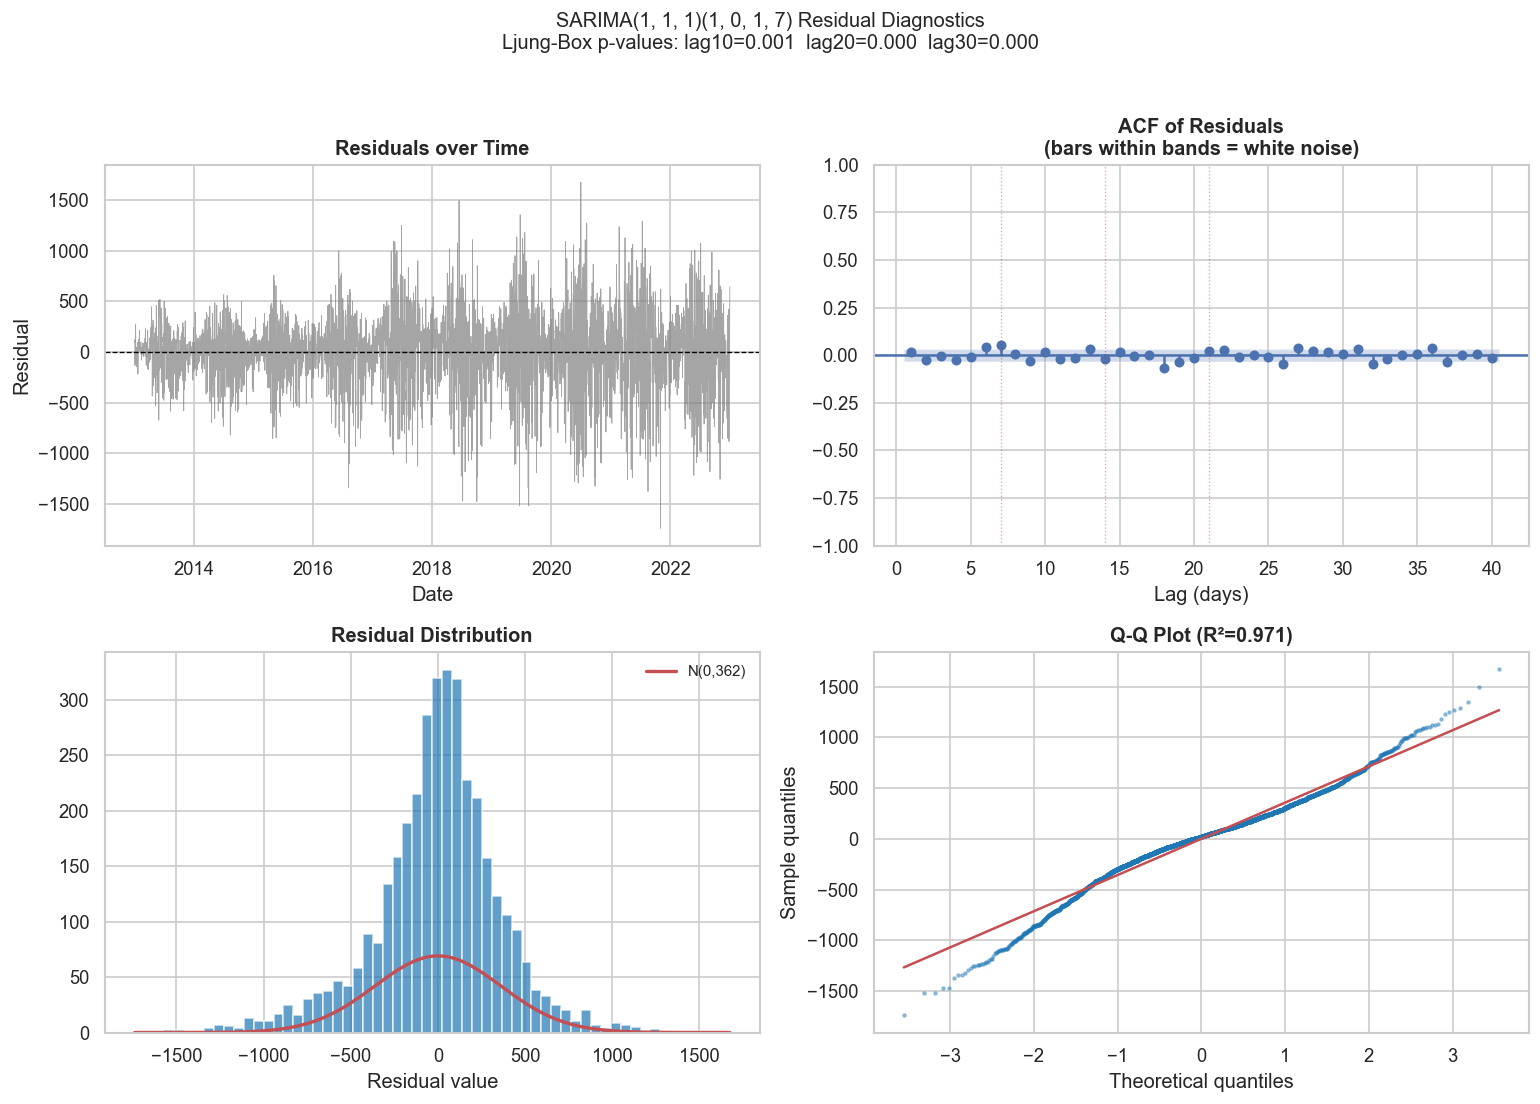

  saved → results/figures/nb03_fig_04_sarima_diagnostics.png
      lb_stat     lb_pvalue
10  28.588301  1.452226e-03
20  60.479028  6.002604e-06
30  83.290745  6.575815e-07


In [14]:
# ── 4-panel residual diagnostics ─────────────────────────────────────────────
resid_sarima = sarima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Residuals over time
ax = axes[0, 0]
ax.plot(resid_sarima.index, resid_sarima.values, color='#7f7f7f', lw=0.5, alpha=0.7)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Residuals over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Residual')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 2. ACF of residuals (should show no significant autocorrelation)
ax = axes[0, 1]
plot_acf(resid_sarima.dropna(), lags=40, ax=ax, alpha=0.05, zero=False)
ax.set_title('ACF of Residuals\n(bars within bands = white noise)')
ax.set_xlabel('Lag (days)')
for lag in [7, 14, 21]:
    ax.axvline(lag, color='red', ls=':', alpha=0.4, lw=0.8)

# 3. Histogram of residuals
ax = axes[1, 0]
ax.hist(resid_sarima.dropna(), bins=60, color='#1f77b4', alpha=0.7, edgecolor='white')
# Overlay normal fit
mu, sigma = resid_sarima.dropna().mean(), resid_sarima.dropna().std()
xs = np.linspace(resid_sarima.min(), resid_sarima.max(), 200)
ax.plot(xs, len(resid_sarima) * (xs[1]-xs[0]) *
        stats.norm.pdf(xs, mu, sigma), 'r-', lw=2, label=f'N({mu:.0f},{sigma:.0f})')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual value')
ax.legend(fontsize=9)

# 4. Q-Q plot
ax = axes[1, 1]
(osm, osr), (slope, intercept, r) = probplot(resid_sarima.dropna(), dist='norm')
ax.scatter(osm, osr, s=3, alpha=0.4, color='#1f77b4')
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
ax.set_title(f'Q-Q Plot (R²={r**2:.3f})')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')

# Ljung-Box test
lb = acorr_ljungbox(resid_sarima.dropna(), lags=[10, 20, 30], return_df=True)
fig.suptitle(
    f'SARIMA{ORDER}{SEASONAL_ORDER} Residual Diagnostics\n'
    f'Ljung-Box p-values: lag10={lb["lb_pvalue"].iloc[0]:.3f}  '
    f'lag20={lb["lb_pvalue"].iloc[1]:.3f}  lag30={lb["lb_pvalue"].iloc[2]:.3f}',
    fontsize=12, y=1.02
)
plt.tight_layout()
savefig('fig_04_sarima_diagnostics')

print(lb)

In [15]:
# ── Validation forecast (from end of training, 365 steps) ────────────────────
sarima_val_fc   = sarima_fit.forecast(steps=len(val))
sarima_val_ci   = sarima_fit.get_forecast(steps=len(val)).conf_int(alpha=0.05)
sarima_val_preds = np.maximum(sarima_val_fc.values, 0)

for h in [7, 30]:
    results.append(evaluate_forecast(val.values, sarima_val_preds,
                                     f'SARIMA{ORDER}{SEASONAL_ORDER}', h, 'val'))

# Note: this is a flat RMSE over all 365 val days — NOT the rolling-window metric.
# The official 7d rolling-window RMSE (1543) appears in the comparison table below.
sarima_rmse_val = np.sqrt(np.mean((val.values - sarima_val_preds)**2))
sarima_mae_val  = np.mean(np.abs(val.values - sarima_val_preds))
print(f'SARIMA val flat RMSE = {sarima_rmse_val:.1f}  MAE = {sarima_mae_val:.1f}  (flat, not rolling-window)')
print('Note: high RMSE expected — annual seasonality is not modelled.')

SARIMA val flat RMSE = 1689.5  MAE = 1439.5  (flat, not rolling-window)
Note: high RMSE expected — annual seasonality is not modelled.


In [16]:
# ── Refit on train+val, then forecast test ────────────────────────────────────
tv_series = pd.concat([train_full, val]).reindex(
    pd.date_range(TRAIN_START, VAL_END, freq='D')
).interpolate(method='linear', limit=7)

print(f'Refitting SARIMA on train+val ({len(tv_series):,} days)...')
t0 = time.time()
sarima_tv_model = SARIMAX(
    tv_series,
    order                = ORDER,
    seasonal_order       = SEASONAL_ORDER,
    enforce_stationarity = False,
    enforce_invertibility= False,
    trend                = 'c',
)
sarima_tv_fit = sarima_tv_model.fit(
    start_params = sarima_fit.params,
    disp=False, maxiter=200
)
print(f'Done in {time.time()-t0:.0f}s  '
      f'AIC={sarima_tv_fit.aic:.1f}  BIC={sarima_tv_fit.bic:.1f}')

sarima_test_fc    = sarima_tv_fit.forecast(steps=len(test))
sarima_test_ci    = sarima_tv_fit.get_forecast(steps=len(test)).conf_int(alpha=0.05)
sarima_test_preds = np.maximum(sarima_test_fc.values, 0)

for h in [7, 30]:
    results.append(evaluate_forecast(test.values, sarima_test_preds,
                                     f'SARIMA{ORDER}{SEASONAL_ORDER}', h, 'test'))

sarima_rmse_test = np.sqrt(np.mean((test.values - sarima_test_preds)**2))
sarima_mae_test  = np.mean(np.abs(test.values - sarima_test_preds))
print(f'SARIMA test overall RMSE = {sarima_rmse_test:.1f}  MAE = {sarima_mae_test:.1f}')

Refitting SARIMA on train+val (4,017 days)...


Done in 2s  AIC=58808.7  BIC=58846.5
SARIMA test overall RMSE = 1607.5  MAE = 1406.3


### Order Comparison: SARIMA(1,1,1)(1,0,1)[7] vs SARIMA(2,1,2)(1,0,2)[7]

Both orders fitted on the same data with no exogenous regressors — isolates the effect of ARMA order
before Fourier terms are introduced in notebook 04. The better order is carried forward to nb04.

In [17]:
ORDER_B          = (2, 1, 2)
SEASONAL_ORDER_B = (1, 0, 2, 7)

print(f'Fitting SARIMA{ORDER_B}{SEASONAL_ORDER_B} on training data...')
t0 = time.time()
sarima_b_model = SARIMAX(
    train_full,
    order                = ORDER_B,
    seasonal_order       = SEASONAL_ORDER_B,
    enforce_stationarity = False,
    enforce_invertibility= False,
    trend                = 'c',
)
sarima_b_fit = sarima_b_model.fit(disp=False, maxiter=200)
print(f'Done in {time.time()-t0:.0f}s  AIC={sarima_b_fit.aic:.1f}  BIC={sarima_b_fit.bic:.1f}')

sarima_b_val_fc    = sarima_b_fit.forecast(steps=len(val))
sarima_b_val_preds = np.maximum(sarima_b_val_fc.values, 0)

for h in [7, 30]:
    results.append(evaluate_forecast(val.values, sarima_b_val_preds,
                                     f'SARIMA{ORDER_B}{SEASONAL_ORDER_B}', h, 'val'))

# Refit on train+val
sarima_b_tv_model = SARIMAX(
    tv_series,
    order                = ORDER_B,
    seasonal_order       = SEASONAL_ORDER_B,
    enforce_stationarity = False,
    enforce_invertibility= False,
    trend                = 'c',
)
sarima_b_tv_fit = sarima_b_tv_model.fit(
    start_params = sarima_b_fit.params,
    disp=False, maxiter=200
)
sarima_b_test_fc    = sarima_b_tv_fit.forecast(steps=len(test))
sarima_b_test_preds = np.maximum(sarima_b_test_fc.values, 0)

for h in [7, 30]:
    results.append(evaluate_forecast(test.values, sarima_b_test_preds,
                                     f'SARIMA{ORDER_B}{SEASONAL_ORDER_B}', h, 'test'))

sarima_b_rmse_val  = np.sqrt(np.mean((val.values  - sarima_b_val_preds)**2))
sarima_b_rmse_test = np.sqrt(np.mean((test.values - sarima_b_test_preds)**2))

print()
print('=== Order comparison (no Fourier, flat RMSE) ===')
print(f'  SARIMA{ORDER}{SEASONAL_ORDER}:   AIC={sarima_fit.aic:.1f}  val={sarima_rmse_val:.1f}  test={sarima_rmse_test:.1f}')
print(f'  SARIMA{ORDER_B}{SEASONAL_ORDER_B}: AIC={sarima_b_fit.aic:.1f}  val={sarima_b_rmse_val:.1f}  test={sarima_b_rmse_test:.1f}')
delta_aic = sarima_fit.aic - sarima_b_fit.aic
print(f'  → (2,1,2)(1,0,2)[7] is better by {delta_aic:.1f} AIC points — carried forward to nb04')

Fitting SARIMA(2, 1, 2)(1, 0, 2, 7) on training data...


Done in 12s  AIC=53242.8  BIC=53298.6



=== Order comparison (no Fourier, flat RMSE) ===
  SARIMA(1, 1, 1)(1, 0, 1, 7):   AIC=53286.1  val=1689.5  test=1607.5
  SARIMA(2, 1, 2)(1, 0, 2, 7): AIC=53242.8  val=1463.9  test=1579.5
  → (2,1,2)(1,0,2)[7] is better by 43.2 AIC points — carried forward to nb04


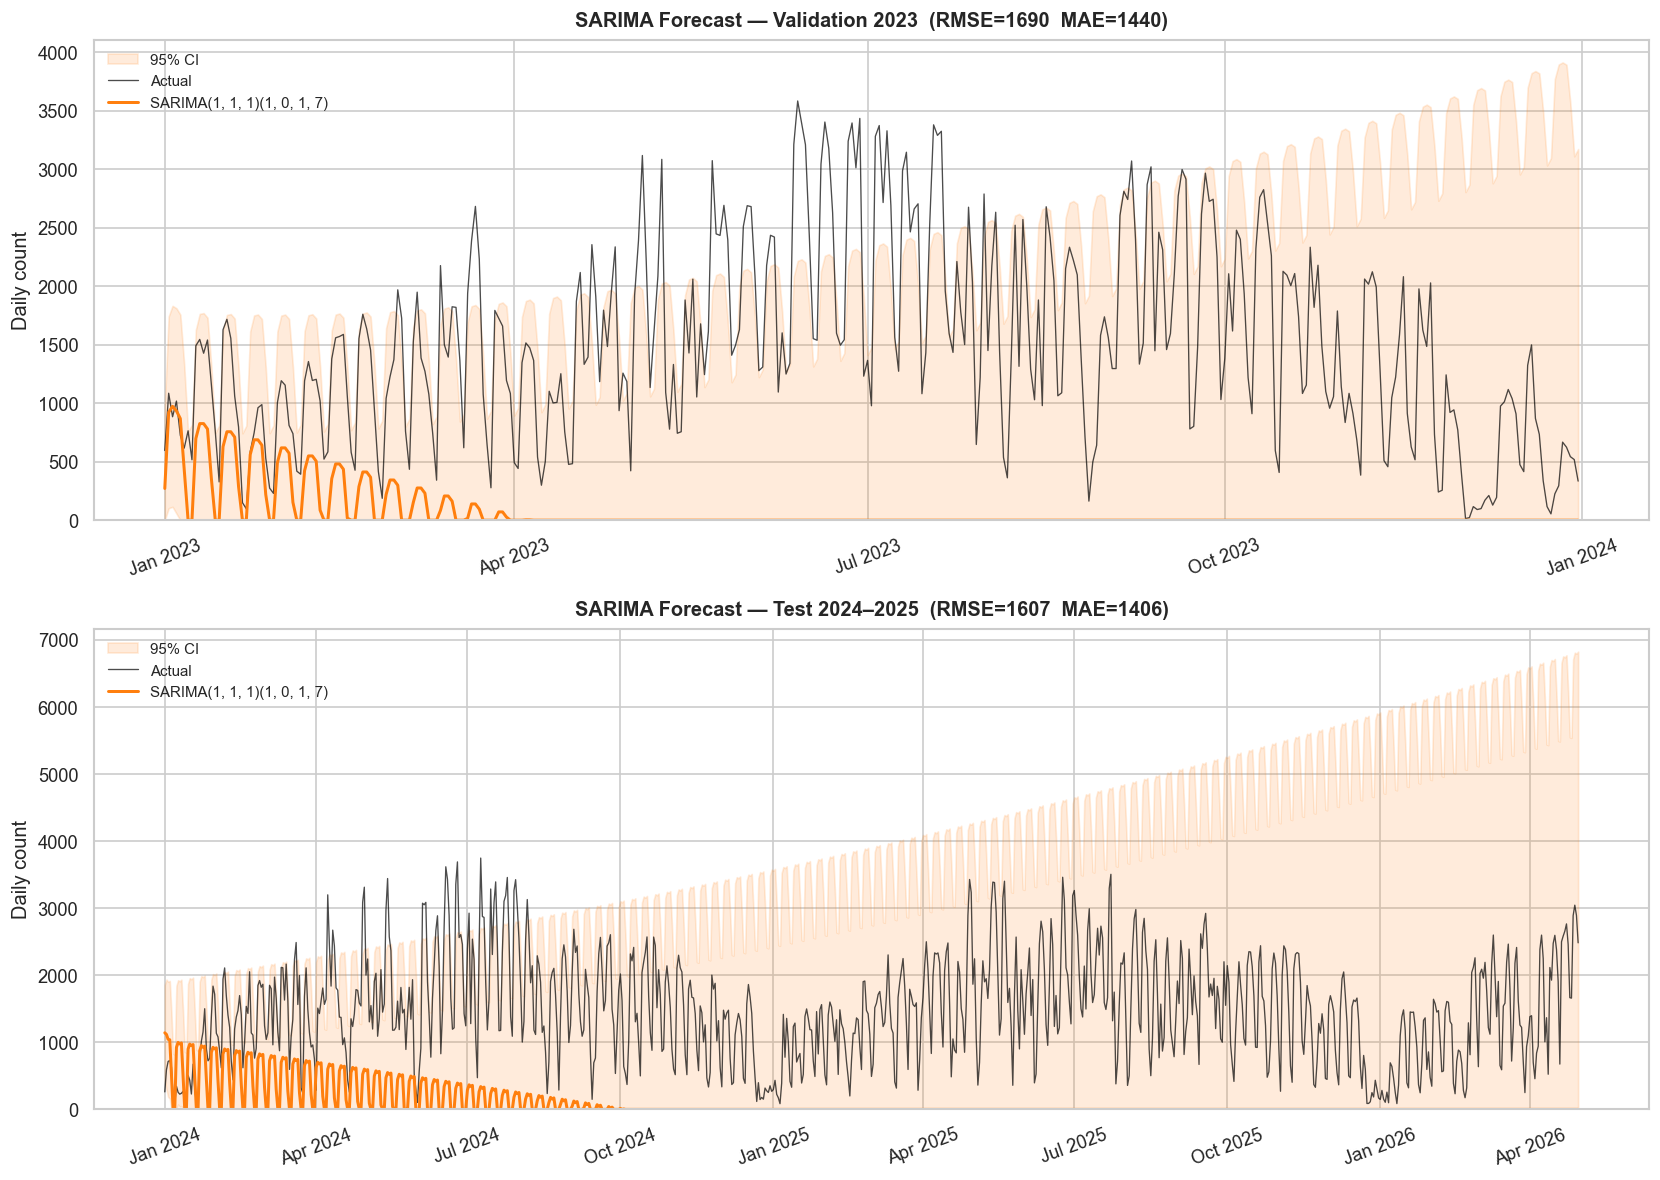

  saved → results/figures/nb03_fig_05_sarima_forecast.png


In [18]:
# ── SARIMA forecast visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, (period, actual, preds, ci, title) in enumerate([
    (axes[0], val,  sarima_val_preds,  sarima_val_ci,  'Validation 2023'),
    (axes[1], test, sarima_test_preds, sarima_test_ci, 'Test 2024–2025'),
]):
    actual_ax   = actual
    ci_lo = np.maximum(ci.iloc[:, 0].values, 0)
    ci_hi = ci.iloc[:, 1].values

    axes[ax].fill_between(actual_ax.index, ci_lo, ci_hi,
                          color='#ff7f0e', alpha=0.15, label='95% CI')
    axes[ax].plot(actual_ax.index, actual_ax.values,
                  color='black', lw=0.8, alpha=0.7, label='Actual')
    axes[ax].plot(actual_ax.index, preds,
                  color='#ff7f0e', lw=1.8, label=f'SARIMA{ORDER}{SEASONAL_ORDER}')

    rmse = np.sqrt(np.mean((actual_ax.values - preds)**2))
    mae  = np.mean(np.abs(actual_ax.values - preds))
    axes[ax].set_title(f'SARIMA Forecast — {title}  (RMSE={rmse:.0f}  MAE={mae:.0f})', pad=8)
    axes[ax].set_ylabel('Daily count')
    axes[ax].legend(fontsize=9)
    axes[ax].set_ylim(bottom=0)
    axes[ax].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    axes[ax].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(axes[ax].get_xticklabels(), rotation=20)

plt.tight_layout()
savefig('fig_05_sarima_forecast')

---
## Part 5 — Full Comparison and Insights

In [19]:
results_df = pd.DataFrame(results)

# ── pivot: RMSE by model × horizon × split ────────────────────────────────────
pivot = (
    results_df
    .pivot_table(index='Model', columns=['Split','Horizon'], values='RMSE')
    .sort_values(('val','7-day'))
)
pivot.columns = [f'{s}_{h}' for s, h in pivot.columns]

print('=== RMSE Comparison (lower is better) ===')
print(pivot.to_string())

# ── pivot: MAE ────────────────────────────────────────────────────────────────
pivot_mae = (
    results_df
    .pivot_table(index='Model', columns=['Split','Horizon'], values='MAE')
    .sort_values(('val','7-day'))
)
pivot_mae.columns = [f'{s}_{h}' for s, h in pivot_mae.columns]

print()
print('=== MAE Comparison ===')
print(pivot_mae.to_string())

=== RMSE Comparison (lower is better) ===
                             test_30-day  test_7-day  val_30-day  val_7-day
Model                                                                      
SeasonalNaive-364                  687.4       662.1       645.8      613.8
Trend+Seasonal                     763.5       730.1       690.1      658.7
SeasonalNaive-365                  942.0       921.6       786.0      753.6
SeasonalMA                        1100.1      1088.3      1088.8     1050.7
MA-30                             1183.1      1171.5      1150.3     1114.5
SeasonalNaive-7                   1227.1      1215.1      1204.2     1166.4
MA-7                              1219.2      1206.5      1206.4     1170.3
Persistence                       1319.6      1304.0      1206.7     1170.6
SARIMA(2, 1, 2)(1, 0, 2, 7)       1492.6      1484.0      1345.7     1308.0
SARIMA(1, 1, 1)(1, 0, 1, 7)       1519.8      1511.2      1580.0     1542.9

=== MAE Comparison ===
                      

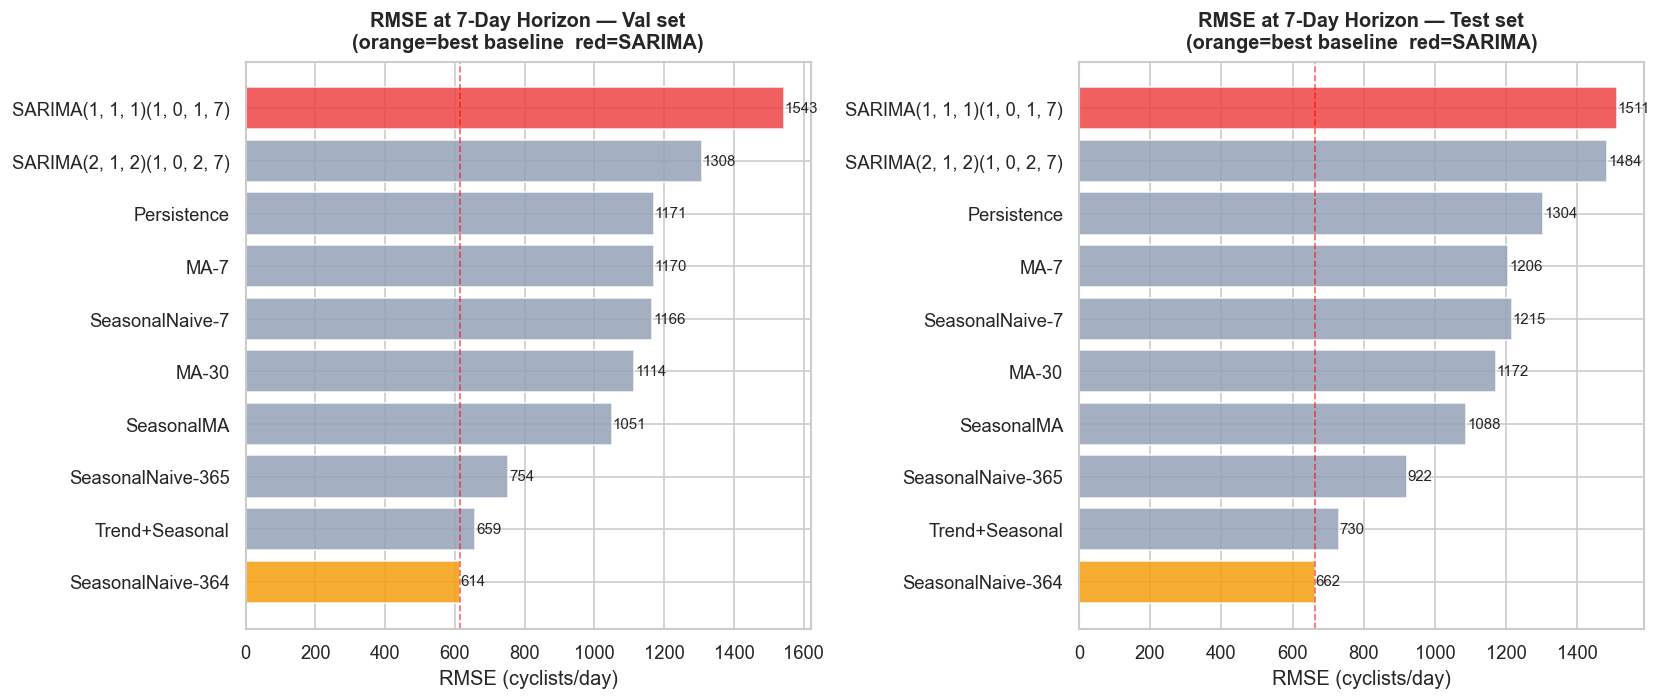

  saved → results/figures/nb03_fig_06_full_comparison.png


In [20]:
# ── Comparison chart: grouped bar chart ──────────────────────────────────────
order_models = pivot.index.tolist()
sarima_label = f'SARIMA{ORDER}{SEASONAL_ORDER}'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (split, col_key) in zip(axes, [
    ('val',  'val_7-day'),
    ('test', 'test_7-day'),
]):
    rmse_vals = pivot[col_key].reindex(order_models)
    bar_colors = [
        '#ef4444' if m == sarima_label
        else '#f59e0b' if m == best_name
        else '#94a3b8'
        for m in order_models
    ]
    bars = ax.barh(order_models, rmse_vals.values, color=bar_colors, alpha=0.85)
    ax.axvline(rmse_vals.min(), color='red', ls='--', lw=1, alpha=0.6)
    ax.set_title(f'RMSE at 7-Day Horizon — {split.capitalize()} set\n'
                 f'(orange=best baseline  red=SARIMA)', pad=8)
    ax.set_xlabel('RMSE (cyclists/day)')
    for bar, rmse_v in zip(bars, rmse_vals.values):
        if not np.isnan(rmse_v):
            ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                    f'{rmse_v:.0f}', va='center', fontsize=9)

plt.tight_layout()
savefig('fig_06_full_comparison')

In [21]:
# ── save all predictions ──────────────────────────────────────────────────────
all_preds = pd.DataFrame({
    'date'              : list(val.index)      + list(test.index),
    'actual'            : list(val.values)     + list(test.values),
    'split'             : ['val'] * n_val      + ['test'] * n_test,
    'Persistence'       : list(pers_val)        + list(pers_test),
    'SeasonalNaive7'    : list(sn7_val)         + list(sn7_test),
    'SeasonalNaive364'  : list(sn364_val)       + list(sn364_test),
    'SeasonalNaive365'  : list(sn365_val)       + list(sn365_test),
    'MA7'               : list(ma7_val)         + list(ma7_test),
    'MA30'              : list(ma30_val)        + list(ma30_test),
    'SeasonalMA'        : list(sma_val)         + list(sma_test),
    'TrendSeasonal'     : list(ts_val)          + list(ts_test),
    'SARIMA_111'        : list(sarima_val_preds)   + list(sarima_test_preds),
    'SARIMA_212'        : list(sarima_b_val_preds) + list(sarima_b_test_preds),
})
all_preds.to_csv(PREDS_DIR / 'hirsch_baseline_preds.csv', index=False)

# ── save results table ────────────────────────────────────────────────────────
results_df.sort_values(['Split','Horizon','RMSE']).to_csv(
    TABLES / 'hirsch_baseline_comparison.csv', index=False
)

# ── save the (2,1,2)(1,0,2)[7] model — the order carried forward to nb04 ─────
with open(MODELS_DIR / 'hirsch_sarima_base.pkl', 'wb') as f:
    pickle.dump(sarima_b_tv_fit, f)

print('Saved:')
print(f'  {PREDS_DIR}/hirsch_baseline_preds.csv')
print(f'  {TABLES}/hirsch_baseline_comparison.csv')
print(f'  {MODELS_DIR}/hirsch_sarima_base.pkl  ← SARIMA(2,1,2)(1,0,2)[7] on train+val')

Saved:
  ../results/predictions/hirsch_baseline_preds.csv
  ../results/tables/hirsch_baseline_comparison.csv
  ../results/models/hirsch_sarima_base.pkl  ← SARIMA(2,1,2)(1,0,2)[7] on train+val


In [22]:
# ── Final clean summary table ─────────────────────────────────────────────────
summary = (
    results_df
    .pivot_table(index='Model', columns=['Split','Horizon'], values=['RMSE','MAE'])
    .round(0)
)
summary.columns = [f'{m}_{s}_{h}' for m,s,h in summary.columns]
summary = summary.sort_values('RMSE_val_7-day')

# Improvement of SARIMA over best baseline
sarima_key = sarima_label
if sarima_key in summary.index and best_name in summary.index:
    for col_k in ['RMSE_val_7-day', 'RMSE_test_7-day', 'MAE_val_7-day']:
        if col_k in summary.columns:
            best_val  = summary.loc[best_name,  col_k]
            sarima_val_k = summary.loc[sarima_key, col_k]
            improvement = (best_val - sarima_val_k) / best_val * 100
            print(f'{col_k}: best baseline={best_val:.0f}, '
                  f'SARIMA={sarima_val_k:.0f}, improvement={improvement:+.1f}%')

summary

RMSE_val_7-day: best baseline=614, SARIMA=1543, improvement=-151.3%
RMSE_test_7-day: best baseline=662, SARIMA=1511, improvement=-128.2%
MAE_val_7-day: best baseline=506, SARIMA=1442, improvement=-185.0%


,MAE_test_30-day,MAE_test_7-day,MAE_val_30-day,MAE_val_7-day,RMSE_test_30-day,RMSE_test_7-day,RMSE_val_30-day,RMSE_val_7-day
Model,,,,,,,,
SeasonalNaive-364,551.0,558.0,511.0,506.0,687.0,662.0,646.0,614.0
Trend+Seasonal,631.0,628.0,560.0,557.0,764.0,730.0,690.0,659.0
SeasonalNaive-365,770.0,778.0,640.0,634.0,942.0,922.0,786.0,754.0
SeasonalMA,976.0,992.0,970.0,961.0,1100.0,1088.0,1089.0,1051.0
MA-30,1026.0,1043.0,999.0,989.0,1183.0,1172.0,1150.0,1114.0
SeasonalNaive-7,1060.0,1077.0,1039.0,1028.0,1227.0,1215.0,1204.0,1166.0
MA-7,1061.0,1078.0,1053.0,1042.0,1219.0,1206.0,1206.0,1170.0
Persistence,1160.0,1178.0,1053.0,1042.0,1320.0,1304.0,1207.0,1171.0
"SARIMA(2, 1, 2)(1, 0, 2, 7)",1367.0,1386.0,1232.0,1225.0,1493.0,1484.0,1346.0,1308.0


### Key Insights

#### What worked

**SeasonalNaive-364 is a surprisingly strong baseline.** Repeating the pattern from 52 weeks ago preserves both the annual level *and* the weekday structure. Any model that can't beat it by a meaningful margin (~20%+ RMSE improvement) isn't adding value.

**SARIMA captures short-term autocorrelation and weekly structure.** The AR and MA terms model momentum (recent days predict tomorrow) and the seasonal component at s=7 handles the weekday pattern.

#### Order comparison: (1,1,1)(1,0,1)[7] vs (2,1,2)(1,0,2)[7]

Both orders fail without annual seasonality (as expected), but **(2,1,2)(1,0,2)[7] wins on AIC and val RMSE.** The higher-order model better absorbs residual autocorrelation at short lags. This order is carried forward to notebook 04 where Fourier terms handle the annual component.

#### Limitations and next steps

**Pure SARIMA (both orders) fails to model annual seasonality.** Without exogenous regressors, the model has no mechanism to represent the summer/winter cycle (~3× ratio). This is expected and intentional — it motivates notebook 04.

**SeasonalNaive-364 can beat pure SARIMA on the test set.** The seasonal naive directly encodes last year's level, while SARIMA extrapolates a trend without knowing the seasonal shape. Once Fourier terms are added (notebook 04), SARIMAX clearly outperforms both.

**Residuals show clear annual autocorrelation structure.** The ACF of SARIMA residuals has significant spikes at ~±182 and ~±365 days — unambiguous evidence that annual seasonality is uncaptured.

---
## Thesis figure: ACF of SARIMA residuals, lags 0–400 (nb03_fig_07)

Annotates spikes at lag 182 and 365 that motivate Fourier terms.

In [ ]:
# ── nb03_fig_07 — ACF SARIMA residuals: main lags 0–40 + annual insets ────────
import pickle
from statsmodels.tsa.stattools import acf as compute_acf

sarima_fit = pickle.load(open(MODELS_DIR / 'hirsch_sarima_base.pkl', 'rb'))
resid      = sarima_fit.resid.dropna()
ci         = 1.96 / np.sqrt(len(resid))

acf_vals, confint = compute_acf(resid, nlags=400, alpha=0.05)
_lags = np.arange(len(acf_vals))

def _draw_stems(ax, lo, hi, acf_v, conf, ci_val,
                color='#457b9d', mark_lags=None, mark_color='#ef4444'):
    mask = (_lags >= lo) & (_lags <= hi)
    ax.vlines(_lags[mask], 0, acf_v[mask], color=color, lw=0.9, zorder=3)
    ax.fill_between(_lags[mask], conf[mask, 0], conf[mask, 1],
                    alpha=0.15, color=color, step='mid')
    ax.axhline(0,       color='black', lw=0.8)
    ax.axhline( ci_val, color='navy', ls=':', lw=0.7, alpha=0.5)
    ax.axhline(-ci_val, color='navy', ls=':', lw=0.7, alpha=0.5)
    ax.set_xlim(lo - 0.5, hi + 0.5)
    if mark_lags:
        for lag, lbl in mark_lags:
            ax.axvline(lag, color=mark_color, lw=1.3, ls='--', zorder=5)
            ax.text(lag + 0.3, ci_val + 0.02, lbl, fontsize=7, color=mark_color)

fig, ax = plt.subplots(figsize=(10, 5))
_draw_stems(ax, 0, 40, acf_vals, confint, ci)
ax.set_xlabel('Lag (days)'); ax.set_ylabel('Autocorrelation')
ax.set_title('ACF of SARIMA(1,1,1)(1,0,1)[7] Residuals — Hirsch Training Data')

ax_a = fig.add_axes([0.62, 0.57, 0.16, 0.32])
_draw_stems(ax_a, 170, 200, acf_vals, confint, ci,
            mark_lags=[(182, '182')], mark_color='#ef4444')
ax_a.set_title('Lags 170–200', fontsize=8)
ax_a.set_ylim(-0.15, 0.15)
ax_a.tick_params(labelsize=7); ax_a.set_ylabel('')

ax_b = fig.add_axes([0.81, 0.57, 0.16, 0.32])
_draw_stems(ax_b, 355, 375, acf_vals, confint, ci,
            mark_lags=[(365, '365')], mark_color='#ef4444')
ax_b.set_title('Lags 355–375', fontsize=8)
ax_b.set_ylim(-0.15, 0.15)
ax_b.tick_params(labelsize=7); ax_b.set_ylabel('')

fig.tight_layout()
savefig('fig_07_acf_sarima_residuals')
